<a href="https://colab.research.google.com/github/Ligohtml/Environment/blob/main/Lect4/ImageFilteringPlaybook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#mount Drive as external disk
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


absolute_path = '/content/drive/My Drive/Didattica/Corsi/AI/Lectures/Lecture4/' #your path on google drive. It should start with /content/drive/My Drive/ and then the name of your folder.

Mounted at /content/drive


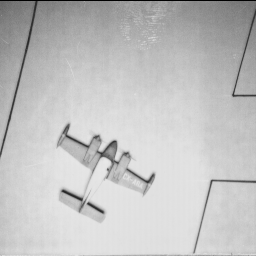

In [ ]:
# read image
src = cv2.imread(absolute_path+'test_images/5.1.11.tiff', 0)
cv2_imshow(src)

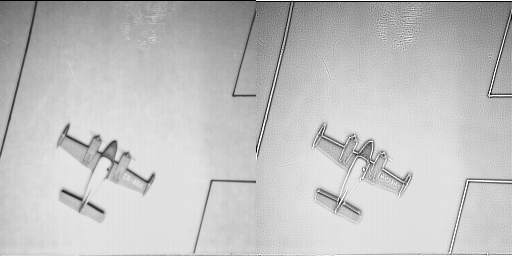

[[255 255 255 ... 255 255 255]
 [  0   0   0 ...   0   0   0]
 [100 100 104 ... 112 113 110]
 ...
 [194 184 196 ... 229 218 217]
 [220 212 224 ... 126 132 134]
 [148 216 119 ... 255 255 255]]
(256, 256)


In [ ]:
# prepare the filter
#kernel = [[0,0,0], [0,1,0], [0,0,0]] #identity
kernel = np.array([[-1,-1,-1],
                   [-1,6,-1],
                   [-1,-1,-1]])

# apply kernel to the original image
filterSum = np.sum(kernel)
if filterSum == 0:  #avoid division by 0
  filterSum = 1
dst = cv2.filter2D(src, -1, 1./filterSum * np.array(kernel)) #convolution of the kernel and the image

# concatenate images horizontally
result = np.concatenate((src, dst), axis=1)
cv2_imshow(result)

print(dst)
print(dst.shape)

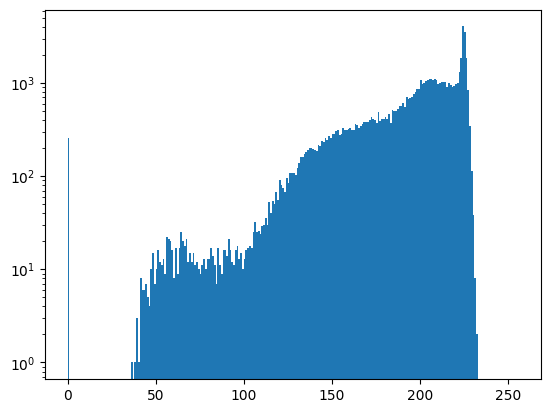

In [ ]:
src2 = src.copy()

plt.hist(src2.ravel(), bins=256, range=[0,256]) #flatten the array with ravel
plt.yscale('log')
plt.show()

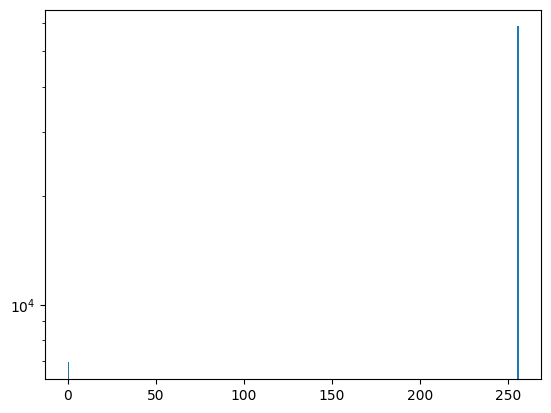

In [ ]:
super_threshold_indices = src2 > 150
src2[super_threshold_indices] = 255

sub_threshold_indices = src2 < 151
src2[sub_threshold_indices] = 0


plt.hist(src2.ravel(), bins=256, range=[0,256]) #flatten the array with ravel
plt.yscale('log')
plt.show()

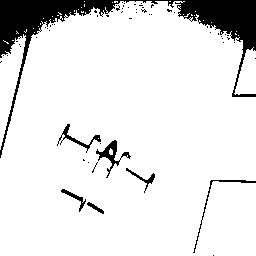

In [ ]:
cv2_imshow(src2)


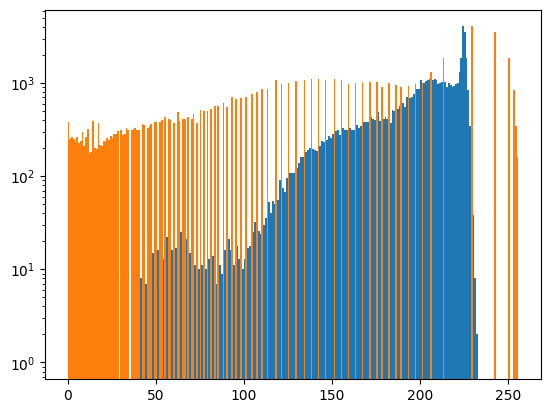

[2.560e+02 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 1.000e+00 0.000e+00 1.000e+00 3.000e+00 1.000e+00 8.000e+00
 6.000e+00 6.000e+00 7.000e+00 5.000e+00 4.000e+00 1.000e+01 1.500e+01
 7.000e+00 1.000e+01 1.600e+01 1.200e+01 1.100e+01 1.300e+01 9.000e+00
 2.200e+01 2.100e+01 2.000e+01 1.600e+01 8.000e+00 1.700e+01 9.000e+00
 1.700e+01 2.500e+01 2.000e+01 1.800e+01 2.100e+01 1.200e+01 1.500e+01
 1.200e+01 1.500e+01 1.100e+01 1.200e+01 1.000e+01 9.000e+00 1.100e+01
 1.300e+01 1.000e+01 1.300e+01 1.300e+01 1.700e+01 1.400e+01 1.100e+01
 7.000e+00 1.700e+01 1.100e+01 9.000e+00 1.600e+01 1.600e+01 1.400e+01
 2.100e+01 1.600e+01 1.200e+01 1.100e+01 1.600e+01 1.800e+01 1.300e+01
 1.500

In [ ]:
src3 = src.copy()

src3 = cv2.equalizeHist(src3)

values, edges, patches = plt.hist(src.ravel(), bins=256, range=[0,256]) #flatten the array with ravel
plt.hist(src3.ravel(), bins=256, range=[0,256]) #flatten the array with ravel
plt.yscale('log')
plt.show()
print(values)
print(edges)

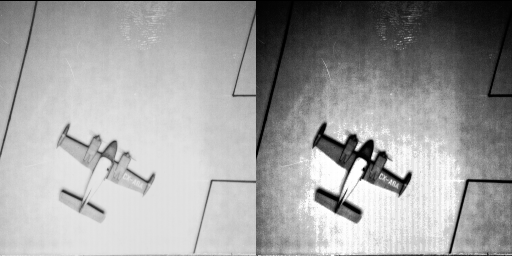

In [ ]:
result = np.concatenate((src, src3), axis=1)
cv2_imshow(result)


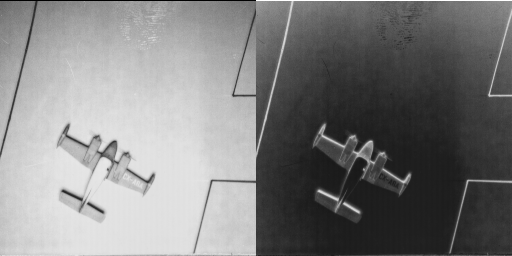

In [ ]:

src4 = src.copy()
src4 = 255 - src4


result = np.concatenate((src, src4), axis=1)
cv2_imshow(result)


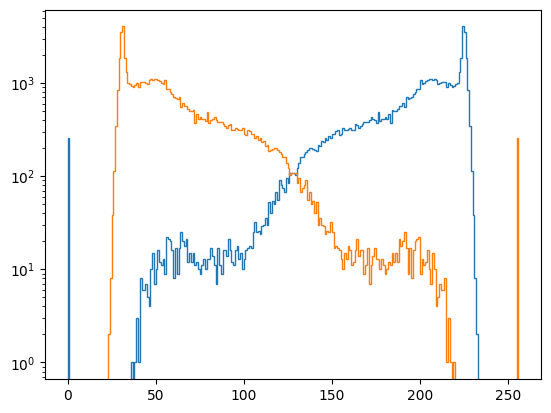

In [ ]:
plt.hist(src.ravel(), bins=256, range=[0,256], histtype=u'step') #flatten the array with ravel
plt.hist(src4.ravel(), bins=256, range=[0,256], histtype=u'step') #flatten the array with ravel

plt.yscale('log')
plt.show()

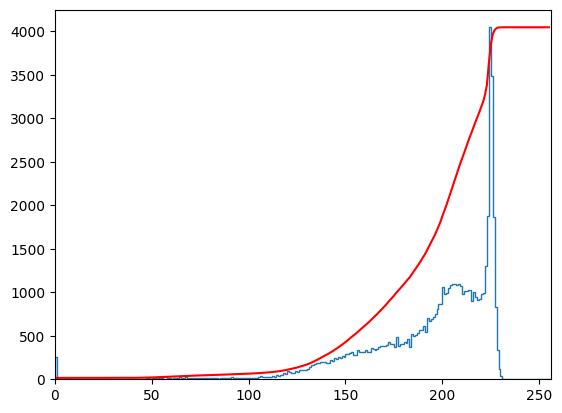

In [ ]:
hist,bins = np.histogram(src.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

plt.hist(src.ravel(), bins=256, range=[0,256], histtype=u'step') #flatten the array with ravel
plt.plot(cdf_normalized, color = 'r')
plt.xlim([0,256])

plt.show()

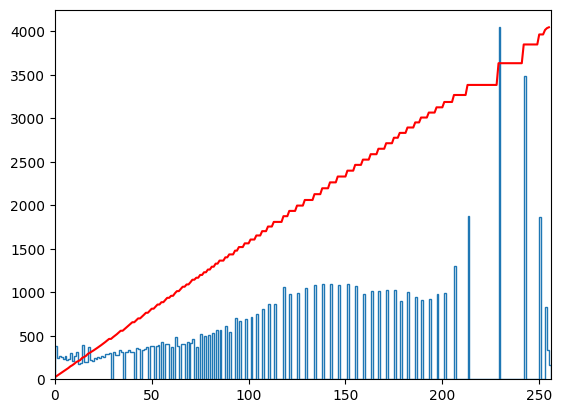

In [ ]:
hist,bins = np.histogram(src3.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

plt.hist(src3.ravel(), bins=256, range=[0,256], histtype=u'step') #flatten the array with ravel
plt.plot(cdf_normalized, color = 'r')
plt.xlim([0,256])

plt.show()